## Task 1.1(a): instalar las librerías en el entorno del kernel.

In [1]:
%pip install geopandas pandas numpy matplotlib requests shapely rasterio

  Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached pyogrio-0.13.0-cp311-abi3-macosx_12_0_arm64.whl.metadata (5.8 kB)
Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 2.8 MB/s  0:00:08m0:00:0100:01
Using cached pyogrio-0.13.0-cp311-abi3-macosx_12_0_arm64.whl (24.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 2.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [geopandas]/6 [geopandas]

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Imports y verificación de versiones

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import shapely
import rasterio

print("Librerías importadas correctamente.")
print(f"Versión de GeoPandas: {gpd.__version__}")
print(f"Versión de Shapely: {shapely.__version__}")

Librerías importadas correctamente.
Versión de GeoPandas: 1.2.0
Versión de Shapely: 2.1.2


## Task 1.1(b): descargar las divisiones administrativas de Argentina.

In [3]:
from pathlib import Path

# Fuente: GADM 4.1.
# ARG corresponde al código de Argentina.
# Nivel 1: provincias y divisiones equivalentes.
# Nivel 2: departamentos, partidos y divisiones equivalentes.

carpeta_datos = Path("datos")
carpeta_datos.mkdir(parents=True, exist_ok=True)

def descargar_gadm(nivel):
    nombre = f"gadm41_ARG_{nivel}.json"
    url = f"https://geodata.ucdavis.edu/gadm/gadm4.1/json/{nombre}"
    ruta = carpeta_datos / nombre

    print(f"Descargando nivel {nivel} desde: {url}")

    respuesta = requests.get(url, timeout=180)
    respuesta.raise_for_status()
    ruta.write_bytes(respuesta.content)

    capa = gpd.read_file(ruta)

    # Verificar el CRS declarado por la fuente.
    if capa.crs is None:
        raise ValueError(f"El nivel {nivel} no tiene un CRS definido.")

    if capa.crs.to_epsg() != 4326:
        raise ValueError(
            f"Se esperaba EPSG:4326 en el nivel {nivel}, "
            f"pero se encontró {capa.crs}."
        )

    print(f"Nivel {nivel}: {len(capa)} divisiones | CRS: {capa.crs}")
    return capa

gadm_nivel1 = descargar_gadm(1)
gadm_nivel2 = descargar_gadm(2)

Descargando nivel 1 desde: https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_ARG_1.json
Nivel 1: 24 divisiones | CRS: EPSG:4326
Descargando nivel 2 desde: https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_ARG_2.json
Nivel 2: 502 divisiones | CRS: EPSG:4326


## Task 1.1(c): ingresar la llave de Healthsites

In [4]:
from getpass import getpass

healthsites_api_key = getpass("Ingresa tu API key de Healthsites: ").strip()

if not healthsites_api_key:
    raise ValueError("No ingresaste una API key.")

print("Llave almacenada en memoria. Pendiente de validar con la API.")

Llave almacenada en memoria. Pendiente de validar con la API.


In [5]:
url_healthsites = "https://healthsites.io/api/v3/facilities/"

parametros = {
    "api-key": healthsites_api_key,
    "country": "Argentina",
    "page": 1,
    "output": "geojson",
}

try:
    respuesta = requests.get(
        url_healthsites,
        params=parametros,
        timeout=90,
    )
except requests.RequestException:
    raise RuntimeError(
        "No se pudo conectar con Healthsites. Revisa tu conexión e intenta de nuevo."
    ) from None

print(f"Código HTTP: {respuesta.status_code}")

if respuesta.status_code != 200:
    raise RuntimeError(
        f"La API devolvió el código {respuesta.status_code}. "
        "La consulta no se completó."
    )

try:
    datos_prueba = respuesta.json()
except ValueError:
    raise RuntimeError("La respuesta no contiene un JSON válido.") from None

print(f"Tipo de respuesta: {type(datos_prueba).__name__}")

if isinstance(datos_prueba, dict):
    print("Campos principales:", list(datos_prueba.keys()))

    if "features" in datos_prueba:
        print("Instalaciones en esta página:", len(datos_prueba["features"]))

        if datos_prueba["features"]:
            primera = datos_prueba["features"][0]
            print("Campos de una instalación:", list(primera.keys()))
            print(
                "Atributos disponibles:",
                list((primera.get("properties") or {}).keys()),
            )

elif isinstance(datos_prueba, list):
    print("Registros en esta página:", len(datos_prueba))

    if datos_prueba and isinstance(datos_prueba[0], dict):
        print("Campos de una instalación:", list(datos_prueba[0].keys()))

Código HTTP: 403


RuntimeError: La API devolvió el código 403. La consulta no se completó.

## Task 1.1(d): descargar el ráster de población de WorldPop

In [7]:
# Task 1.1(d): descarga programática de WorldPop.
# Producto: Global2 R2025A, versión 1.
# Territorio: Argentina.
# Año: 2030, último disponible en esta serie (proyección futura).
# Resolución nominal: 1 km.
# Unidad de los valores: habitantes por celda.
# Catálogo: https://hub.worldpop.org/geodata/listing?id=136

anio_worldpop = 2030

nombre_worldpop = (
    f"arg_pop_{anio_worldpop}_CN_1km_R2025A_UA_v1.tif"
)

url_worldpop = (
    "https://data.worldpop.org/GIS/Population/"
    f"Global_2015_2030/R2025A/{anio_worldpop}/ARG/"
    f"v1/1km_ua/constrained/{nombre_worldpop}"
)

ruta_worldpop = carpeta_datos / nombre_worldpop
ruta_temporal = ruta_worldpop.with_suffix(".tif.part")

print(f"Descargando población proyectada de Argentina para {anio_worldpop}...")

with requests.get(url_worldpop, stream=True, timeout=180) as descarga:
    descarga.raise_for_status()

    with open(ruta_temporal, "wb") as archivo:
        for bloque in descarga.iter_content(chunk_size=1024 * 1024):
            if bloque:
                archivo.write(bloque)

ruta_temporal.replace(ruta_worldpop)

with rasterio.open(ruta_worldpop) as raster:
    print("GeoTIFF abierto correctamente.")
    print(f"CRS: {raster.crs}")
    print(f"Filas: {raster.height}")
    print(f"Columnas: {raster.width}")

print(f"Archivo guardado en: {ruta_worldpop}")
print(f"Tamaño: {ruta_worldpop.stat().st_size / (1024 ** 2):.2f} MB")

Descargando población proyectada de Argentina para 2030...
GeoTIFF abierto correctamente.
CRS: EPSG:4326
Filas: 3994
Columnas: 2390
Archivo guardado en: datos/arg_pop_2030_CN_1km_R2025A_UA_v1.tif
Tamaño: 5.63 MB


In [8]:
from pyproj import Geod

geod = Geod(ellps="WGS84")

with rasterio.open(ruta_worldpop) as raster:
    poblacion = raster.read(1, masked=True)
    poblacion = np.ma.masked_invalid(poblacion)

    crs_worldpop = raster.crs
    filas, columnas = raster.height, raster.width
    transformacion = raster.transform
    resolucion_x, resolucion_y = raster.res

    if raster.crs.to_epsg() != 4326:
        raise ValueError("Esta celda espera un ráster en EPSG:4326.")

    if transformacion.b != 0 or transformacion.d != 0:
        raise ValueError("Esta celda espera un ráster sin rotación.")

    lon_centro, lat_centro = raster.xy(filas // 2, columnas // 2)

    _, _, ancho_m = geod.inv(
        lon_centro - resolucion_x / 2, lat_centro,
        lon_centro + resolucion_x / 2, lat_centro,
    )
    _, _, alto_m = geod.inv(
        lon_centro, lat_centro - resolucion_y / 2,
        lon_centro, lat_centro + resolucion_y / 2,
    )

    areas_filas_km2 = np.empty(filas)
    oeste = raster.bounds.left
    este = oeste + resolucion_x

    for fila in range(filas):
        norte = transformacion.f + fila * transformacion.e
        sur = norte + transformacion.e

        area_m2, _ = geod.polygon_area_perimeter(
            [oeste, este, este, oeste],
            [norte, norte, sur, sur],
        )
        areas_filas_km2[fila] = abs(area_m2) / 1_000_000

    densidad = poblacion / areas_filas_km2[:, np.newaxis]

    resumen_worldpop = pd.DataFrame([{
        "Año (proyección)": anio_worldpop,
        "CRS": str(crs_worldpop),
        "Filas": filas,
        "Columnas": columnas,
        "Ancho en el centro (m)": round(ancho_m, 2),
        "Alto en el centro (m)": round(alto_m, 2),
        "Máximo de habitantes por celda": round(float(poblacion.max()), 2),
        "Densidad máxima (hab/km²)": round(float(densidad.max()), 2),
    }])

display(resumen_worldpop)

,Año (proyección),CRS,Filas,Columnas,Ancho en el centro (m),Alto en el centro (m),Máximo de habitantes por celda,Densidad máxima (hab/km²)
0,2030,EPSG:4326,3994,2390,727.65,925.04,26718.29,37807.31


## Task 1.2(a): revisar la extensión antes de elegir el CRS proyectado.

In [9]:
oeste, sur, este, norte = gadm_nivel1.total_bounds

extension_territorio = pd.DataFrame([{
    "Longitud mínima": oeste,
    "Longitud máxima": este,
    "Latitud mínima": sur,
    "Latitud máxima": norte,
    "Extensión longitudinal (grados)": este - oeste,
    "Extensión latitudinal (grados)": norte - sur,
}])

display(extension_territorio.round(4))

limites_provincias = gadm_nivel1[["NAME_1"]].join(
    gadm_nivel1.geometry.bounds
).rename(columns={
    "NAME_1": "División",
    "minx": "Oeste",
    "miny": "Sur",
    "maxx": "Este",
    "maxy": "Norte",
})

display(
    limites_provincias
    .sort_values("División")
    .reset_index(drop=True)
    .round(4)
)

,Longitud mínima,Longitud máxima,Latitud mínima,Latitud máxima,Extensión longitudinal (grados),Extensión latitudinal (grados)
0,-73.5606,-53.5918,-55.0615,-21.7814,19.9688,33.2801


,División,Oeste,Sur,Este,Norte
0,BuenosAires,-63.3939,-41.0354,-56.6674,-33.2601
1,Catamarca,-69.0900,-30.1224,-64.8247,-25.1563
2,Chaco,-63.4276,-28.0000,-58.3639,-24.0931
3,Chubut,-72.1882,-46.0067,-63.5826,-41.9964
4,CiudaddeBuenosAires,-58.5313,-34.7090,-58.3351,-34.5318
5,Corrientes,-59.6889,-30.7554,-55.6163,-27.2477
6,Córdoba,-65.7783,-34.9984,-61.7777,-29.5033
7,EntreRíos,-60.7567,-34.0438,-57.8013,-30.1632
8,Formosa,-62.3476,-26.8719,-57.5541,-22.4616
9,Jujuy,-67.2154,-24.6127,-64.1554,-21.7814


In [10]:
from pyproj import Proj

longitudes = np.arange(oeste, este + 0.5, 0.5)
latitudes = np.arange(sur, norte + 0.5, 0.5)
lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

puntos_evaluacion = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(
        lon_grid.ravel(),
        lat_grid.ravel(),
    ),
    crs="EPSG:4326",
)

territorio = gadm_nivel1.geometry.union_all()
puntos_evaluacion = puntos_evaluacion[
    puntos_evaluacion.geometry.within(territorio)
].copy()

candidatos = {
    "EPSG:32719": "WGS 84 / UTM zona 19S",
    "EPSG:32720": "WGS 84 / UTM zona 20S",
    "EPSG:32721": "WGS 84 / UTM zona 21S",
}

comparacion = []

for epsg, nombre in candidatos.items():
    proyeccion = Proj(epsg)

    factores = proyeccion.get_factors(
        puntos_evaluacion.geometry.x.to_numpy(),
        puntos_evaluacion.geometry.y.to_numpy(),
    )

    escala = np.asarray(factores.meridional_scale)
    error_porcentaje = np.abs(escala - 1) * 100

    comparacion.append({
        "EPSG": epsg,
        "Proyección": nombre,
        "Error medio de escala (%)": error_porcentaje.mean(),
        "Error máximo muestreado (%)": error_porcentaje.max(),
    })

comparacion_crs = pd.DataFrame(comparacion).sort_values(
    "Error máximo muestreado (%)"
).reset_index(drop=True)

print(f"Puntos evaluados dentro de Argentina: {len(puntos_evaluacion)}")
display(comparacion_crs.round(4))

Puntos evaluados dentro de Argentina: 1106


,EPSG,Proyección,Error medio de escala (%),Error máximo muestreado (%)
0,EPSG:32720,WGS 84 / UTM zona 20S,0.1633,0.9538
1,EPSG:32721,WGS 84 / UTM zona 21S,0.7264,2.0268
2,EPSG:32719,WGS 84 / UTM zona 19S,0.3279,2.7688


## Task 1.2(a): reproyección de las capas administrativas.

In [11]:
crs_proyectado = "EPSG:32720"

gadm_nivel1_m = gadm_nivel1.to_crs(crs_proyectado)
gadm_nivel2_m = gadm_nivel2.to_crs(crs_proyectado)

verificacion_crs = pd.DataFrame([
    {
        "Capa": "GADM nivel 1",
        "Divisiones": len(gadm_nivel1_m),
        "CRS": gadm_nivel1_m.crs.to_string(),
        "Unidad": gadm_nivel1_m.crs.axis_info[0].unit_name,
    },
    {
        "Capa": "GADM nivel 2",
        "Divisiones": len(gadm_nivel2_m),
        "CRS": gadm_nivel2_m.crs.to_string(),
        "Unidad": gadm_nivel2_m.crs.axis_info[0].unit_name,
    },
])

display(verificacion_crs)

,Capa,Divisiones,CRS,Unidad
0,GADM nivel 1,24,EPSG:32720,metre
1,GADM nivel 2,502,EPSG:32720,metre


In [12]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

ruta_worldpop_m = carpeta_datos / (
    f"arg_pop_{anio_worldpop}_EPSG32720_1000m.tif"
)

with rasterio.open(ruta_worldpop) as origen:
    datos_originales = np.ma.masked_invalid(origen.read(1, masked=True))
    total_original = float(datos_originales.sum(dtype=np.float64))

    transformacion_m, ancho, alto = calculate_default_transform(
        origen.crs,
        crs_proyectado,
        origen.width,
        origen.height,
        *origen.bounds,
        resolution=1000,
    )

    perfil = origen.profile.copy()
    perfil.update(
        crs=crs_proyectado,
        transform=transformacion_m,
        width=ancho,
        height=alto,
        dtype="float64",
        nodata=-9999.0,
        compress="deflate",
    )

    with rasterio.open(ruta_worldpop_m, "w", **perfil) as destino:
        reproject(
            source=rasterio.band(origen, 1),
            destination=rasterio.band(destino, 1),
            src_transform=origen.transform,
            src_crs=origen.crs,
            src_nodata=origen.nodata,
            dst_transform=transformacion_m,
            dst_crs=crs_proyectado,
            dst_nodata=-9999.0,
            resampling=Resampling.sum,
        )

with rasterio.open(ruta_worldpop_m) as raster_m:
    datos_reproyectados = np.ma.masked_invalid(
        raster_m.read(1, masked=True)
    )
    total_reproyectado = float(
        datos_reproyectados.sum(dtype=np.float64)
    )

    print(f"CRS: {raster_m.crs}")
    print(f"Resolución: {raster_m.res} metros")
    print(f"Filas: {raster_m.height} | Columnas: {raster_m.width}")

diferencia_porcentaje = (
    (total_reproyectado - total_original) / total_original * 100
)

display(pd.DataFrame([{
    "Población del ráster original": total_original,
    "Población del ráster reproyectado": total_reproyectado,
    "Diferencia (%)": diferencia_porcentaje,
}]).round(4))

CRS: EPSG:32720
Resolución: (1000.0, 1000.0) metros
Filas: 3745 | Columnas: 2067


,Población del ráster original,Población del ráster reproyectado,Diferencia (%)
0,4.651507e+07,4.651507e+07,0.0


## Task 1.2(b): mapa base parcial

In [13]:
from rasterio.features import rasterize

provincias_m = gadm_nivel1_m.reset_index(drop=True).copy()
provincias_m["id_raster"] = np.arange(1, len(provincias_m) + 1)

with rasterio.open(ruta_worldpop_m) as raster:
    poblacion_m = np.ma.masked_invalid(
        raster.read(1, masked=True)
    )

    zonas = rasterize(
        shapes=[
            (geometria, int(identificador))
            for geometria, identificador in zip(
                provincias_m.geometry,
                provincias_m["id_raster"],
            )
        ],
        out_shape=(raster.height, raster.width),
        transform=raster.transform,
        fill=0,
        all_touched=False,
        dtype="int32",
    )

    poblacion_por_zona = np.bincount(
        zonas.ravel(),
        weights=poblacion_m.filled(0).ravel(),
        minlength=len(provincias_m) + 1,
    )

tabla_provincias = pd.DataFrame({
    "GID_1": provincias_m["GID_1"],
    "División": provincias_m["NAME_1"],
    "Área (km²)": provincias_m.geometry.area / 1_000_000,
    "Población estimada 2030": poblacion_por_zona[
        provincias_m["id_raster"].to_numpy()
    ],
})

display(
    tabla_provincias
    .sort_values("División")
    .reset_index(drop=True)
    .round(2)
)

poblacion_total_territorio = tabla_provincias[
    "Población estimada 2030"
].sum()

print(
    "Población asignada al territorio GADM: "
    f"{poblacion_total_territorio:,.2f} habitantes"
)

,GID_1,División,Área (km²),Población estimada 2030
0,ARG.1_1,BuenosAires,307308.60,17671823.26
1,ARG.2_1,Catamarca,101652.89,432116.09
2,ARG.3_1,Chaco,99859.96,1156426.86
3,ARG.4_1,Chubut,225409.84,597056.53
4,ARG.5_1,CiudaddeBuenosAires,211.91,3147853.20
5,ARG.7_1,Corrientes,89474.46,1206224.36
6,ARG.6_1,Córdoba,164618.09,4014075.48
7,ARG.8_1,EntreRíos,78201.25,1441262.13
8,ARG.9_1,Formosa,75736.43,612876.08
9,ARG.10_1,Jujuy,53198.99,805768.50


Población asignada al territorio GADM: 46,384,258.26 habitantes


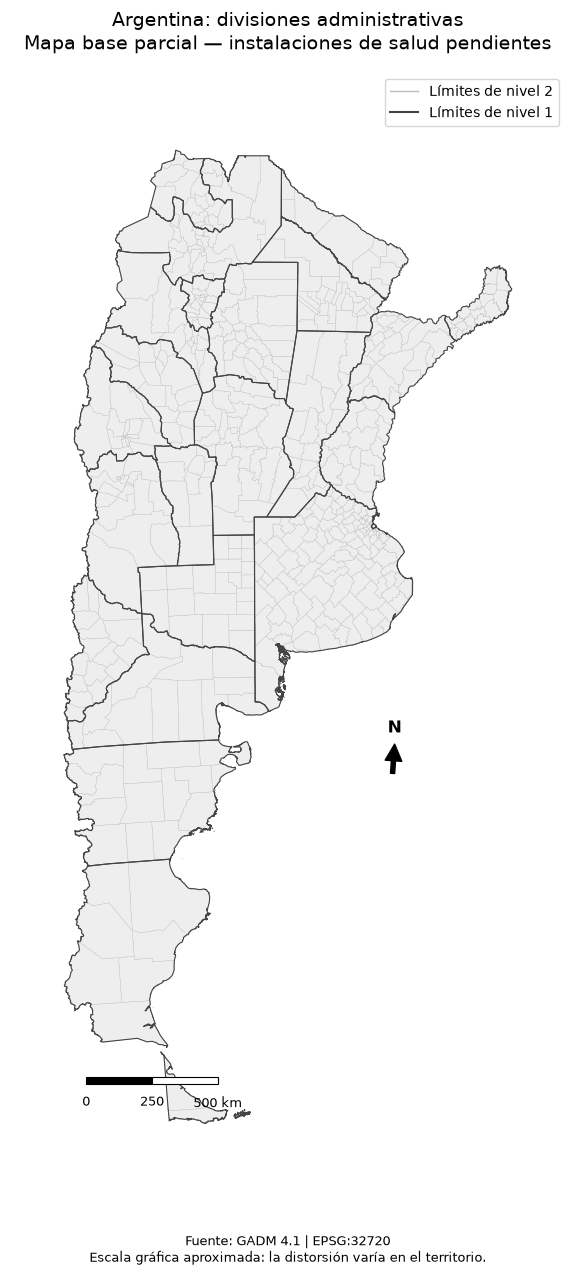

In [14]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 13))

# Nivel 2: relleno gris claro y límites finos.
gadm_nivel2_m.plot(
    ax=ax,
    facecolor="#eeeeee",
    edgecolor="#bbbbbb",
    linewidth=0.25,
)

# Nivel 1: contornos sin relleno.
gadm_nivel1_m.boundary.plot(
    ax=ax,
    color="#444444",
    linewidth=0.8,
)

xmin, ymin, xmax, ymax = gadm_nivel1_m.total_bounds
ancho = xmax - xmin
alto = ymax - ymin

ax.set_xlim(xmin - 0.12 * ancho, xmax + 0.12 * ancho)
ax.set_ylim(ymin - 0.08 * alto, ymax + 0.08 * alto)
ax.set_aspect("equal")

# Escala gráfica de 500 km, dividida en dos segmentos.
# Las coordenadas del mapa están expresadas en metros.
x_escala = xmin + 0.05 * ancho
y_escala = ymin + 0.04 * alto
segmento = 250_000

for i, color in enumerate(["black", "white"]):
    rectangulo = plt.Rectangle(
        (x_escala + i * segmento, y_escala),
        segmento,
        0.008 * alto,
        facecolor=color,
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
    )
    ax.add_patch(rectangulo)

for i, etiqueta in enumerate(["0", "250", "500 km"]):
    ax.text(
        x_escala + i * segmento,
        y_escala - 0.012 * alto,
        etiqueta,
        ha="center",
        va="top",
        fontsize=9,
    )

# Norte geográfico: transformar dos puntos del mismo meridiano.
# Así la flecha contempla la orientación de la proyección.
referencia_norte = gpd.GeoSeries(
    gpd.points_from_xy([-57, -57], [-43, -42]),
    crs="EPSG:4326",
).to_crs(crs_proyectado)

base_norte = referencia_norte.iloc[0]
punta_norte = referencia_norte.iloc[1]

ax.annotate(
    "",
    xy=(punta_norte.x, punta_norte.y),
    xytext=(base_norte.x, base_norte.y),
    arrowprops=dict(facecolor="black", edgecolor="black", width=3),
)
ax.text(
    punta_norte.x,
    punta_norte.y + 0.012 * alto,
    "N",
    ha="center",
    fontsize=12,
    fontweight="bold",
)

ax.legend(
    handles=[
        Line2D([0], [0], color="#bbbbbb", lw=1,
               label="Límites de nivel 2"),
        Line2D([0], [0], color="#444444", lw=1.5,
               label="Límites de nivel 1"),
    ],
    loc="upper right",
    frameon=True,
)

ax.set_title(
    "Argentina: divisiones administrativas\n"
    "Mapa base parcial — instalaciones de salud pendientes",
    fontsize=14,
)
ax.set_axis_off()

fig.text(
    0.5, 0.025,
    "Fuente: GADM 4.1 | EPSG:32720\n"
    "Escala gráfica aproximada: la distorsión varía en el territorio.",
    ha="center",
    fontsize=9,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()